# 5.3.1 由条件概率推导贝叶斯更新

## 学习目标与先修知识

能从联合表计算条件概率（conditional probability），区分先验（prior）、似然（likelihood）、证据/边际似然（evidence or marginal likelihood）与后验（posterior）；处理零证据和反复使用同一份数据的条件独立（conditional independence）边界。

先修：5.2.2 的联合表和边缘概率（probability）；概率加权与归一化。 [复习上一节](../02-期望、方差、协方差与噪声/03-过程测量与个体差异.ipynb)。

## 具体问题

细胞中只有 20% 活跃，活跃者有 90% 概率出现某标记，静息者也有 10% 概率出现标记。看到标记之后，活跃概率为什么不是 90%？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
prior=np.array([.2,.8]);likelihood=np.array([.9,.1]);joint=prior*likelihood
display(Markdown(show_table(['状态','先验','出现标记的联合概率'],zip(['活跃','静息'],prior,joint))))

| 状态 | 先验 | 出现标记的联合概率 |
| --- | --- | --- |
| 活跃 | 0.2 | 0.18 |
| 静息 | 0.8 | 0.08 |

## 模型假设

两状态（state）互斥且穷尽，模型（model）给定先验与标记条件概率。观测（observation）标记后，我们更新对原有状态的判断。重复标记只在给定状态后独立的假设下相乘，同一记录的复制不满足该假设。

## 数学解释与推导

P(A|B)=P(A∩B)/P(B)，前提是 P(B)>0。它表示只在 B 已发生的结果中，A 占多少。交换条件方向，P(A∩B)=P(B|A)P(A)，得到 Bayes 公式。对穷尽假设 Hᵢ 和观测 y：
$$P(H_i|y)=\frac{P(y|H_i)P(H_i)}{\sum_j P(y|H_j)P(H_j)}.$$
P(Hᵢ) 是先验；将固定观测 y 看成不同假设的函数，P(y|Hᵢ) 是似然；分母是证据/边际似然 P(y)；结果是后验。此处观测离散，证据 P(y) 是概率；连续观测对应的证据 p(y) 是边际密度，不宜称为普通概率数值。连续观测的似然也可以是密度，不能一概要求不大于 1。

活跃与静息的未归一化权重为 0.18、0.08，分母 0.26，后验分别为 9/13、4/13。高似然会提高相对权重，但不能忽略先验。

若某假设先验为零，有限似然无法把它更新成正概率。若全部权重为零，模型排除了此次观测，普通公式未定义；应检查模型或数据，而不是随意返回均匀后验。对于给定 H 条件独立的 y1、y2，P(y1,y2|H)=P(y1|H)P(y2|H)；复制同一结果没有提供第二份独立信息。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def discrete_update(prior, likelihood):
    weights = [p*l for p,l in zip(prior,likelihood)]
    evidence = sum(weights)
    if evidence == 0:
        return None
    return [w/evidence for w in weights]

## 对照实验

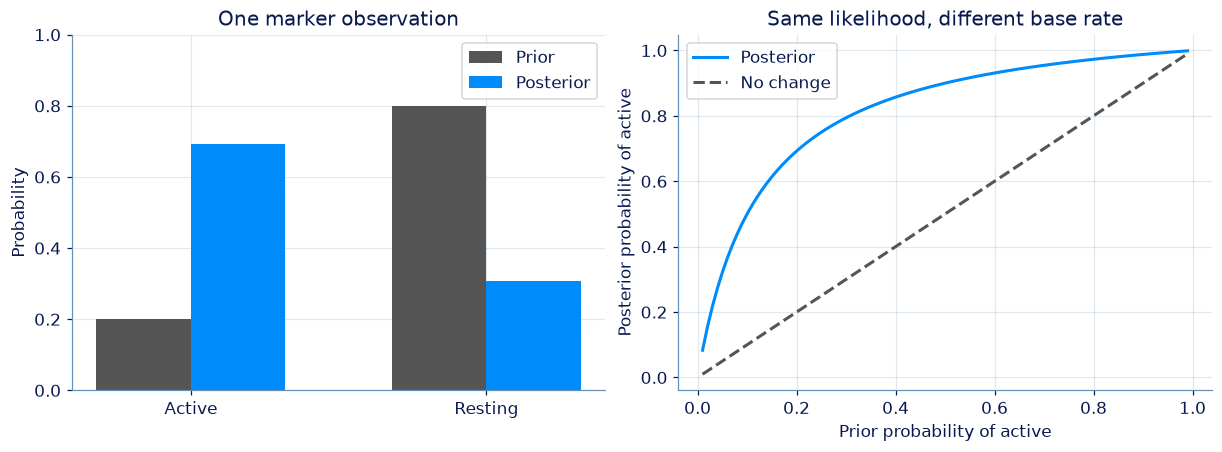

标记出现后的分布： [0.6923076923076924, 0.30769230769230776]
零证据返回： None


In [4]:
base_rates=np.linspace(.01,.99,99)
post=[discrete_update([p,1-p],[.9,.1])[0] for p in base_rates]
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].bar(np.arange(2)-.16,prior,width=.32,color=GRAY,label='Prior')
axes[0].bar(np.arange(2)+.16,discrete_update(prior,likelihood),width=.32,color=BLUE,label='Posterior')
axes[0].set(xticks=[0,1],xticklabels=['Active','Resting'],ylabel='Probability',ylim=(0,1),title='One marker observation');axes[0].legend()
axes[1].plot(base_rates,post,color=BLUE,label='Posterior');axes[1].plot(base_rates,base_rates,color=GRAY,ls='--',label='No change')
axes[1].set(xlabel='Prior probability of active',ylabel='Posterior probability of active',title='Same likelihood, different base rate');axes[1].legend()
plt.show()
print('标记出现后的分布：',discrete_update([.2,.8],[.9,.1]))
print('零证据返回：',discrete_update([1,0],[0,1]))

## 结果解释

标记增加活跃状态的相对可信度，但后验仍受基础比例影响。右图固定了标记机制，仅改变先验；它不是不同测量精度之间的比较。

### 独立核对

用 Fraction 精确联合概率（joint probability）独立核算，不只比较两个浮点归一化实现。

In [5]:
from fractions import Fraction
exact=Fraction(2,10)*Fraction(9,10)/(Fraction(2,10)*Fraction(9,10)+Fraction(8,10)*Fraction(1,10))
assert exact==Fraction(9,13)
np.testing.assert_allclose(discrete_update([.2,.8],[.9,.1]),[float(exact),1-float(exact)])
assert discrete_update([1,0],[0,1]) is None
np.testing.assert_allclose(discrete_update([.2,.8],[1,1]),[.2,.8])
print('有理数联合概率、无信息观测及零证据边界一致。')

有理数联合概率、无信息观测及零证据边界一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-03-条件概率与贝叶斯更新/explore/)：改变一个条件，比较实现、分布（distribution）与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按新观测更新细胞状态概率

观测（observation）只报告标记是否出现。给定各状态（state）先验（prior）与此次观测的似然（likelihood），返回后验（posterior）。

**函数与代码模板**

```python
def solve(
    prior: list[float],
    likelihood: list[float],
) -> list[float] | None:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior` | `list[float]` | 互斥且穷尽假设的先验概率（probability）。 | 1 |
| `likelihood` | `list[float]` | 同一离散观测在各假设下出现的概率。 | 1 |

**返回值**

直接返回 posterior（list[float] | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `posterior` | <code>list[float] &#124; None</code> | 按原顺序返回后验；证据/边际似然（evidence or marginal likelihood）为零时返回 None。 | 1 |

**计算规则**

weights[i]=prior[i]*likelihood[i]；分母为 weights 之和。分母>0 时逐项归一化；分母恰为 0 返回 None，不杜撰均匀后验。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 列表等长，长度 1—20；prior 非负且和为 1（误差≤1e−12）；likelihood 每项在 [0,1]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior | 互斥且穷尽假设的先验概率（probability）。 | [0.2, 0.8] | 1 |
| likelihood | 同一离散观测在各假设下出现的概率。 | [0.9, 0.1] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior = [0.2, 0.8]
likelihood = [0.9, 0.1]

result = solve(prior, likelihood)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| posterior | 按原顺序返回后验；证据/边际似然（evidence or marginal likelihood）为零时返回 None。 | [0.6923076923076924, 0.30769230769230776] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.6923076923076924, 0.30769230769230776]
```

**样例解释**

未归一化权重为 [0.18,0.08]，证据/边际似然为 0.26；后验为 [9/13,4/13]。0.9 是似然，不是后验。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：按新观测更新细胞状态概率](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-bayes)

### 第 2 题 · 单项选择题：似然高为何后验仍未到九成

活跃态先验（prior） 0.2，静息态 0.8；标记出现概率（probability）分别为 0.9、0.1。出现标记后活跃态概率为多少？

- **A.** 0.2。
- **B.** 0.9。
- **C.** 0.18。
- **D.** 9/13。

[作答：似然高为何后验仍未到九成](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-base-rate)

### 第 3 题 · 单项选择题：同一结果能更新两次吗

同一个传感器读数被复制为两条记录。若使用条件独立（conditional independence）观测（observation）公式更新两次，会怎样？

- **A.** 正确，因为记录条数翻倍。
- **B.** 重复计入同一证据，通常使后验（posterior）过度集中。
- **C.** 等价于一次更新。
- **D.** 自动补足先验（prior）为零的状态（state）。

[作答：同一结果能更新两次吗](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-duplicate-observation)

### 第 4 题 · 多项选择题：联合表怎样变成条件表

联合表 p(X,Y) 非负且总和为 1。要求 p(X|Y=y)，哪些成立？

- **A.** 列和为零时仍能任意设定为均匀分布（distribution）。
- **B.** 归一化后的各 X 概率（probability）之和为 1（分母>0）。
- **C.** 只要对整个表除以 1 就得到条件表。
- **D.** 先取 y 对应列，再除以该列和。

[作答：联合表怎样变成条件表](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-conditioning)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 2、21 讲：条件概率、Bayes 与推断。